In [1]:
from pathlib import Path
import json

RAW_DATA_PATH = Path("../data/raw")

print("Files inside raw folder:\n")

for file in RAW_DATA_PATH.iterdir():
    print(file.name)

Files inside raw folder:

.gitkeep
categories.json
database.db
podcasts.json
reviews.json


In [2]:
podcast_file = RAW_DATA_PATH / "podcasts.json"

print("Podcast file path:\n")
print(podcast_file)

Podcast file path:

..\data\raw\podcasts.json


In [3]:
with open(podcast_file, "r", encoding="utf-8") as f:
    
    # Read only first line
    first_line = f.readline()

sample = json.loads(first_line)

print(type(sample))

<class 'dict'>


In [4]:
print("Podcast Keys:\n")

print(sample.keys())

Podcast Keys:

dict_keys(['podcast_id', 'itunes_id', 'slug', 'itunes_url', 'title', 'author', 'description', 'average_rating', 'ratings_count', 'scraped_at'])


In [5]:
for key, value in sample.items():
    print(f"{key}: {type(value)}")

podcast_id: <class 'str'>
itunes_id: <class 'str'>
slug: <class 'str'>
itunes_url: <class 'str'>
title: <class 'NoneType'>
author: <class 'NoneType'>
description: <class 'NoneType'>
average_rating: <class 'NoneType'>
ratings_count: <class 'NoneType'>
scraped_at: <class 'NoneType'>


In [6]:
print("Sample Podcast:\n")

for key, value in sample.items():
    print(f"{key}:")
    print(value)
    print("-" * 50)

Sample Podcast:

podcast_id:
d3997f1089be9e45fda4113be39765cb
--------------------------------------------------
itunes_id:
1000000618
--------------------------------------------------
slug:
christianity-questions-and-answers
--------------------------------------------------
itunes_url:
https://podcasts.apple.com/us/podcast/christianity-questions-and-answers/id1000000618
--------------------------------------------------
title:
None
--------------------------------------------------
author:
None
--------------------------------------------------
description:
None
--------------------------------------------------
average_rating:
None
--------------------------------------------------
ratings_count:
None
--------------------------------------------------
scraped_at:
None
--------------------------------------------------


In [7]:
categories_file = RAW_DATA_PATH / "categories.json"

with open(categories_file, "r", encoding="utf-8") as f:
    first_line = f.readline()

category_sample = json.loads(first_line)

print(type(category_sample))

print("\nKeys:\n")

print(category_sample.keys())

<class 'dict'>

Keys:

dict_keys(['podcast_id', 'itunes_id', 'category'])


In [8]:
for key, value in category_sample.items():
    print(f"{key}: {type(value)}")

podcast_id: <class 'str'>
itunes_id: <class 'str'>
category: <class 'str'>


In [9]:
valid_samples = []

with open(podcast_file, "r", encoding="utf-8") as f:
    
    for line in f:
        record = json.loads(line)
        
        # Keep only records with description
        if record.get("description"):
            valid_samples.append(record)
        
        # Stop after finding 3 valid samples
        if len(valid_samples) == 3:
            break

print(f"Found {len(valid_samples)} valid samples.\n")

Found 3 valid samples.



In [10]:
for i, podcast in enumerate(valid_samples, 1):
    
    print(f"\n========== SAMPLE {i} ==========\n")
    
    for key, value in podcast.items():
        print(f"{key}:")
        print(value)
        print("-" * 50)


========== SAMPLE 1 ==========

podcast_id:
f201172864310534ae6b6c4f8ae9b8cc
--------------------------------------------------
itunes_id:
1000016089
--------------------------------------------------
slug:
rahdo-talks-through
--------------------------------------------------
itunes_url:
https://podcasts.apple.com/us/podcast/rahdo-talks-through/id1000016089
--------------------------------------------------
title:
Rahdo Talks Through
--------------------------------------------------
author:
noreply@blogger.com (Richard Ham)
--------------------------------------------------
description:
Richard "Rahdo" Ham talks (at great length) all about boardgames!
--------------------------------------------------
average_rating:
4.6
--------------------------------------------------
ratings_count:
60
--------------------------------------------------
scraped_at:
2019-07-08 06:15:45.106345
--------------------------------------------------

========== SAMPLE 2 ==========

podcast_id:
6c476d3dd90

In [11]:
total_records = 0
valid_title = 0
valid_description = 0

with open(podcast_file, "r", encoding="utf-8") as f:
    
    for line in f:
        record = json.loads(line)
        
        total_records += 1
        
        if record.get("title"):
            valid_title += 1
            
        if record.get("description"):
            valid_description += 1

print(f"Total Records: {total_records}")
print(f"Valid Titles: {valid_title}")
print(f"Valid Descriptions: {valid_description}")

Total Records: 2077665
Valid Titles: 153821
Valid Descriptions: 149808


In [12]:
description_lengths = []

with open(podcast_file, "r", encoding="utf-8") as f:
    
    for line in f:
        record = json.loads(line)
        
        description = record.get("description")
        
        if description:
            description_lengths.append(len(description))

print(f"Total Valid Descriptions: {len(description_lengths)}")

print(f"Minimum Length: {min(description_lengths)}")
print(f"Maximum Length: {max(description_lengths)}")

avg_length = sum(description_lengths) / len(description_lengths)

print(f"Average Length: {avg_length:.2f}")

Total Valid Descriptions: 149808
Minimum Length: 1
Maximum Length: 3897
Average Length: 276.31


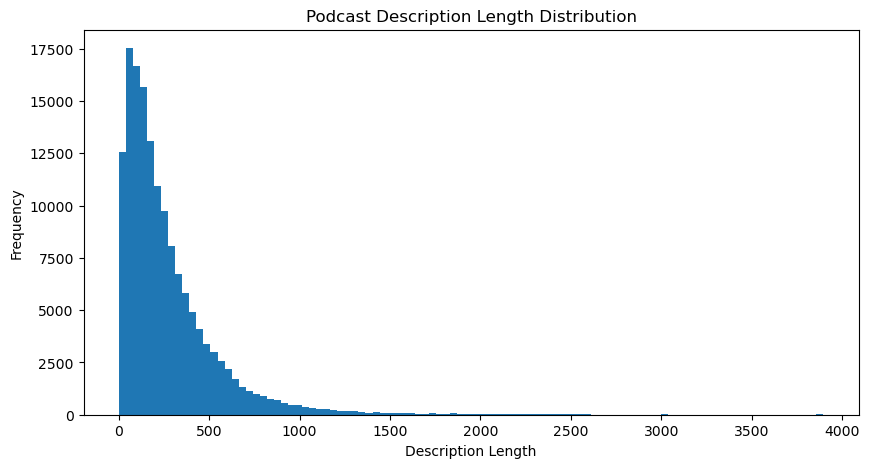

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(description_lengths, bins=100)

plt.xlabel("Description Length")
plt.ylabel("Frequency")
plt.title("Podcast Description Length Distribution")

plt.show()

In [14]:
short_descriptions = []

with open(podcast_file, "r", encoding="utf-8") as f:
    
    for line in f:
        record = json.loads(line)
        
        description = record.get("description")
        
        if description and len(description) < 50:
            short_descriptions.append(description)
        
        if len(short_descriptions) == 20:
            break

for i, desc in enumerate(short_descriptions, 1):
    print(f"\n{i}. {desc}")


1. Podcast by IdiotSpeakShow

2. 热爱生活 活在当下。

3. Stories from Sydney

4. A Radio Show from the City of Fahlstaff

5. Ceachtanna maisithe gramadaigh

6. Vyoma Vyapi Pada Mantram

7. Real estate podcast

8. News from GreenSpirit

9. Podcast by Crítica Americanista

10. Podcast by Veronica G and Samuel B

11. Podcast by Roberto Aguilar

12. Podcast by www.ffch.net

13. Podcast by Insert Coin To Continue

14. Sraith cláir ar théamaí litríochta na hardteiste

15. Podcast by Hot Probs

16. Weekly messages from Kol Dodi Messianic Community

17. Podcast by K. John Abraham

18. Podcast by René Postma

19. The Naked Truth from a Libertarian American

20. Podcast que fala de internet na internet


In [15]:
good_descriptions = []

with open(podcast_file, "r", encoding="utf-8") as f:
    
    for line in f:
        record = json.loads(line)
        
        description = record.get("description")
        
        if description and len(description) > 200:
            good_descriptions.append(description)
        
        if len(good_descriptions) == 5:
            break

for i, desc in enumerate(good_descriptions, 1):
    print(f"\n========== GOOD DESCRIPTION {i} ==========\n")
    print(desc[:1000])


========== GOOD DESCRIPTION 1 ==========

Much bigger than sports, the show is fun, topical, and slightly irreverent. Shaquille O'Neal talks news, entertainment, controversy, and the crazy life of the Diesel himself. He and his sports sidekick, John Kincade never know who will show up to shoot the proverbial shh..uh, well, you know. To access the archive, go to PodcastOne.com.

========== GOOD DESCRIPTION 2 ==========

The name Galaktacus originates from a youthful mispronunciation of a classic comic book character best known for eating planets. Before all of the blockbuster film franchises and the non-stop spoiler-filled internet coverage there was limited space to openly discuss such topics let alone their proper pronunciations. ("Is it Mag-neato or Mag-net-o?") So with that in mind, what started as a long-running, inside joke has now become a word that best defines the spirit of this podcast—looking at comic books, sci-fi, film, television, music, literature and gaming from the per

In [16]:
import numpy as np

print("Description Length Statistics:\n")

print(f"25th Percentile: {np.percentile(description_lengths, 25):.0f}")
print(f"50th Percentile (Median): {np.percentile(description_lengths, 50):.0f}")
print(f"75th Percentile: {np.percentile(description_lengths, 75):.0f}")
print(f"90th Percentile: {np.percentile(description_lengths, 90):.0f}")

Description Length Statistics:

25th Percentile: 96
50th Percentile (Median): 193
75th Percentile: 360
90th Percentile: 586
